In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("insurance.csv")

# See first 5 rows
df.head()

,age,sex,bmi,dependents,smoker,charges
0,19,female,27.900,0,yes,16884.92
1,18,male,33.770,1,no,1725.55
2,28,male,33.000,3,no,4449.46
3,33,male,22.705,0,no,21984.47
4,32,male,28.880,0,no,3866.86


In [2]:
df.shape

(1338, 6)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   age         1338 non-null   int64  
 1   sex         1338 non-null   str    
 2   bmi         1338 non-null   float64
 3   dependents  1338 non-null   int64  
 4   smoker      1338 non-null   str    
 5   charges     1338 non-null   float64
dtypes: float64(2), int64(2), str(2)
memory usage: 72.2 KB


In [4]:
df.describe()

,age,bmi,dependents,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422414
std,14.049960,6.098187,1.205493,12110.011240
min,18.000000,15.960000,0.000000,1121.870000
25%,27.000000,26.296250,0.000000,4740.287500
50%,39.000000,30.400000,1.000000,9382.030000
75%,51.000000,34.693750,2.000000,16639.915000
max,64.000000,53.130000,5.000000,63770.430000


In [5]:
df.isnull().sum()

age           0
sex           0
bmi           0
dependents    0
smoker        0
charges       0
dtype: int64

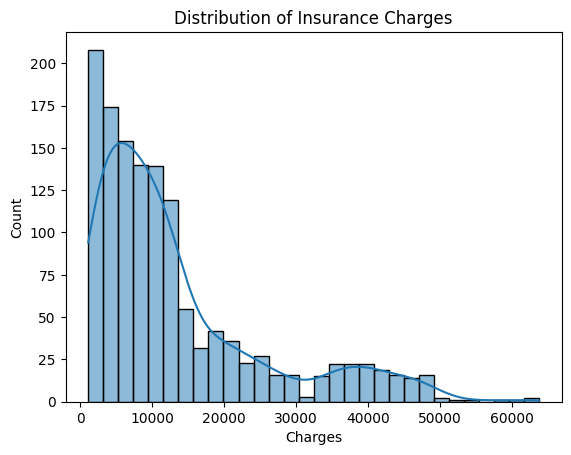

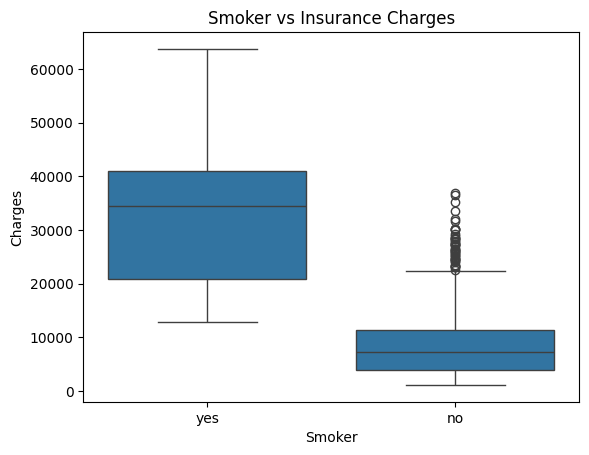

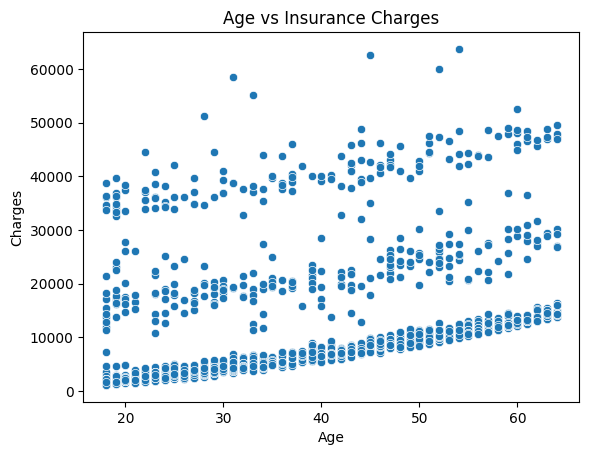

In [6]:
# ================================
# Distribution of Insurance Charges
# ================================


sns.histplot(df["charges"], kde=True)

plt.title("Distribution of Insurance Charges")  # Title of the graph
plt.xlabel("Charges")                           # X-axis label
plt.ylabel("Count")                             # Y-axis label
plt.show()                                      # Display the plot


# ================================
#   Smoker vs Insurance Charges
# ================================


sns.boxplot(x="smoker", y="charges", data=df)

plt.title("Smoker vs Insurance Charges")
plt.xlabel("Smoker")
plt.ylabel("Charges")
plt.show()


# ================================
#    Age vs Insurance Charges
# ================================


sns.scatterplot(x="age", y="charges", data=df)

plt.title("Age vs Insurance Charges")
plt.xlabel("Age")
plt.ylabel("Charges")
plt.show()

In [7]:
# ================================
# Convert Categorical Variables using One-Hot Encoding
# ================================

df["bmi_age"] = df["bmi"] * df["age"]

df_encoded = pd.get_dummies(df, drop_first=True)

df_encoded.head()

,age,bmi,dependents,charges,bmi_age,sex_male,smoker_yes
0,19,27.900,0,16884.92,530.100,False,True
1,18,33.770,1,1725.55,607.860,True,False
2,28,33.000,3,4449.46,924.000,True,False
3,33,22.705,0,21984.47,749.265,True,False
4,32,28.880,0,3866.86,924.160,True,False


In [8]:
# ================================
# Define Features (X) and Target (y)
# ================================

X = df_encoded.drop("charges", axis=1)  # All columns except charges
y = df_encoded["charges"]               # Only charges column

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
X_test.shape

(268, 6)

In [11]:
X_train.shape

(1070, 6)

In [12]:
# =====================================
# Train Linear Regression Model
# =====================================

from sklearn.linear_model import LinearRegression

# Create model object
model = LinearRegression()

# Train the model using training data
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [13]:
# =====================================
# Make Predictions on Test Data
# =====================================

y_pred = model.predict(X_test)

In [14]:
# =====================================
# Evaluate Model Performance
# =====================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R2 Score:", r2)

Mean Absolute Error (MAE): 4221.697256414307
Mean Squared Error (MSE): 34136967.08765843
Root Mean Squared Error (RMSE): 5842.684921135011
R2 Score: 0.7801143605610047


In [15]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients

,Feature,Coefficient
0,age,300.837968
1,bmi,381.436996
2,dependents,425.770610
3,bmi_age,-1.410203
4,sex_male,3.508023
5,smoker_yes,23647.529863


In [16]:
print("Intercept:", model.intercept_)

Intercept: -13775.978655142035


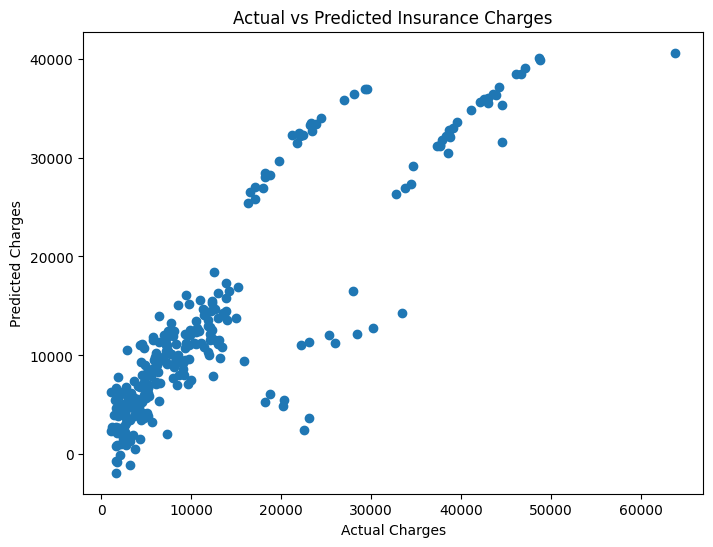

In [17]:
# =====================================
# Compare Actual vs Predicted Charges
# =====================================

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Insurance Charges")
plt.show()

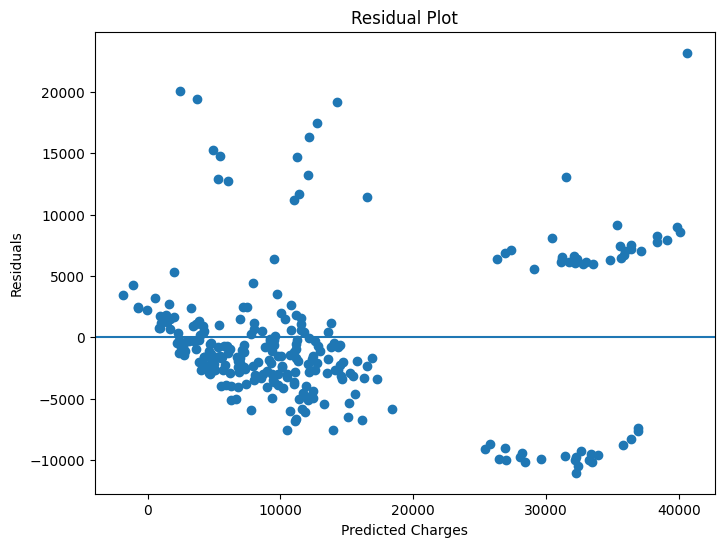

In [18]:
# =====================================
# Residual Plot
# =====================================

residuals = y_test - y_pred

plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Charges")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [31]:
# =====================================
# Train Random Forest Regressor
# =====================================

from sklearn.ensemble import RandomForestRegressor

# Create model
rf_model = RandomForestRegressor(
    n_estimators=400,
    max_depth=12,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42
)

# Train model
rf_model.fit(X_train, y_train)

# Make predictions
rf_pred = rf_model.predict(X_test)

# Evaluate
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = rf_mse ** 0.5
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)
print("Random Forest R2:", rf_r2)

Random Forest MAE: 2424.3713709504914
Random Forest RMSE: 4514.402941974274
Random Forest R2: 0.8687278573341433


In [32]:
print("Linear Regression R2:", r2)
print("Random Forest R2:", rf_r2)

Linear Regression R2: 0.7801143605610047
Random Forest R2: 0.8687278573341433


      Feature  Importance
5  smoker_yes    0.634862
1         bmi    0.186234
0         age    0.102475
3     bmi_age    0.059073
2  dependents    0.013913
4    sex_male    0.003442


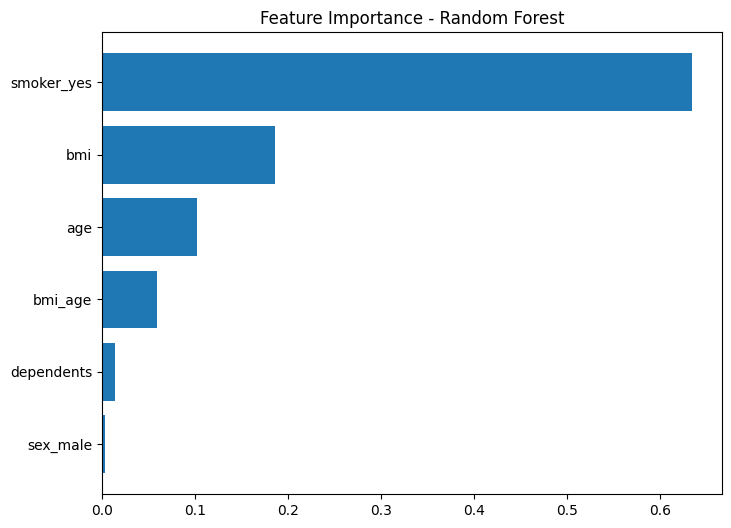

In [33]:
# =====================================
# Feature Importance (Random Forest)
# =====================================

import pandas as pd
import matplotlib.pyplot as plt

importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print(feature_importance)

# Plot
plt.figure(figsize=(8,6))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance - Random Forest")
plt.show()

In [34]:
# =====================================
# Apply Log Transformation to Target
# =====================================

import numpy as np

y_log = np.log(df_encoded["charges"])

In [35]:
X = df_encoded.drop("charges", axis=1)

X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

In [36]:
# Train Linear Regression on log-transformed target

log_model = LinearRegression()
log_model.fit(X_train_log, y_train_log)

# Predict
log_pred = log_model.predict(X_test_log)

In [37]:
# Convert log predictions back to original scale

log_pred_exp = np.exp(log_pred)
y_test_exp = np.exp(y_test_log)

In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

log_mae = mean_absolute_error(y_test_exp, log_pred_exp)
log_rmse = mean_squared_error(y_test_exp, log_pred_exp) ** 0.5
log_r2 = r2_score(y_test_exp, log_pred_exp)

print("Log Linear Regression MAE:", log_mae)
print("Log Linear Regression RMSE:", log_rmse)
print("Log Linear Regression R2:", log_r2)

Log Linear Regression MAE: 3937.635256324679
Log Linear Regression RMSE: 7935.6636124245915
Log Linear Regression R2: 0.594362186036932


In [39]:
# =====================================
# Train Final Random Forest on Full Data
# =====================================

from sklearn.ensemble import RandomForestRegressor
import joblib

X_full = df_encoded.drop("charges", axis=1)
y_full = df_encoded["charges"]

final_model = RandomForestRegressor(random_state=42)
final_model.fit(X_full, y_full)

# Save model
joblib.dump(rf_model, "insurance_model.pkl")

print("Model saved successfully!")

Model saved successfully!
